In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from agent import FloodWarningEnv
import random

eval_env = FloodWarningEnv()

# PPO.load causes fixed seed
model = PPO.load("./models/nonorm/best_model-SEED1/best_model")
np.random.seed(2)

# Runs trained agent over 10000 episodes, records action taken, tru impact level, impact score, 
# whether correct, false alarm, missed warning
def evaluate(model, env, n_episodes=10000):
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        action, _ = model.predict(obs, deterministic=True)
        impact_level = env._get_impact_level(env.env.impact)
        results.append({
            "action": int(action),
            "impact_level": impact_level,
            "impact_score": env.env.impact,
            "correct": int(action) == impact_level,
            "false_alarm": int(action) > impact_level,
            "missed": int(action) < impact_level,
            "level_diff": int(action) - impact_level,
        })
    return pd.DataFrame(results)

df = evaluate(model, eval_env)

print(f"Accuracy:        {df['correct'].mean():.2%}")
print(f"False alarms:    {df['false_alarm'].mean():.2%}")
print(f"Missed warnings: {df['missed'].mean():.2%}")
print(f"Mean level diff: {df['level_diff'].mean():.3f}")
print()
print("Per impact level accuracy:")
print(df.groupby("impact_level")["correct"].mean())

Accuracy:        69.58%
False alarms:    3.22%
Missed warnings: 27.20%
Mean level diff: -0.306

Per impact level accuracy:
impact_level
0    0.955022
1    0.056861
2    0.000000
3    0.000000
Name: correct, dtype: float64


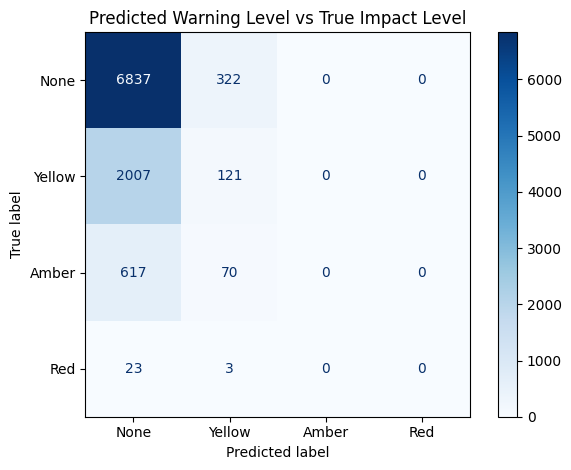

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix, shows predicted vs true warning levels
labels = ["None", "Yellow", "Amber", "Red"]
cm = confusion_matrix(df["impact_level"], df["action"], labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Predicted Warning Level vs True Impact Level")
plt.tight_layout()
#plt.savefig("./results/confusion_matrix.png")
plt.show()

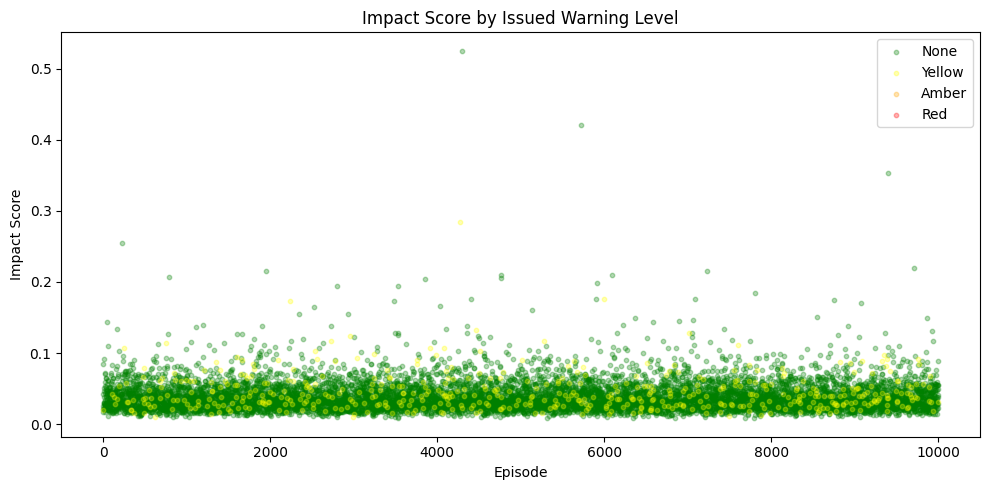

In [3]:
# Scatter plot showing which impact scores the agent assigned each warning to
plt.figure(figsize=(10, 5))
colors = {0: "green", 1: "yellow", 2: "orange", 3: "red"}
for action in [0, 1, 2, 3]:
    subset = df[df["action"] == action]
    plt.scatter(subset.index, subset["impact_score"], 
                c=colors[action], label=labels[action], alpha=0.3, s=10)
plt.xlabel("Episode")
plt.ylabel("Impact Score")
plt.title("Impact Score by Issued Warning Level")
plt.legend()
plt.tight_layout()
#plt.savefig("./results/impact_vs_action.png")
plt.show()

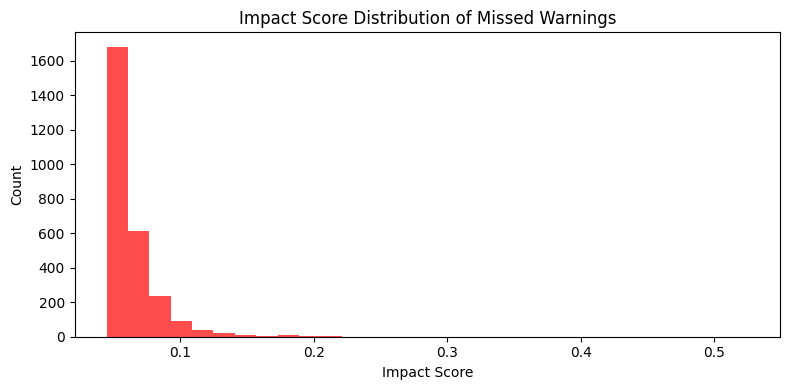

In [4]:
# Histogram of impact score for missed warnings (shows if agent missed minor events or severe ones)
missed_df = df[df["missed"]]
plt.figure(figsize=(8, 4))
plt.hist(missed_df["impact_score"], bins=30, color="red", alpha=0.7)
plt.xlabel("Impact Score")
plt.ylabel("Count")
plt.title("Impact Score Distribution of Missed Warnings")
plt.tight_layout()
#plt.savefig("./results/missed_warnings.png")
plt.show()